# Predicción de abandono de clientes

## Notebook 02: modelamiento y evaluación

En este notebook se entrenan y comparan distintos modelos de clasificación
para predecir la probabilidad de abandono de los clientes.

Los modelos serán evaluados mediante accuracy, balanced accuracy, precision,
recall, F1-score, ROC-AUC y PR-AUC.

In [35]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [36]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
MODELS_PATH = PROJECT_ROOT / "models"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

MODELS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("Carpeta del proyecto:", PROJECT_ROOT)
print("Carpeta de datos:", PROCESSED_PATH)

Carpeta del proyecto: c:\Users\vfuen\Documents\telco-customer-churn-mle2
Carpeta de datos: c:\Users\vfuen\Documents\telco-customer-churn-mle2\data\processed


In [37]:
df_train = pd.read_csv(PROCESSED_PATH / "train.csv")
df_validation = pd.read_csv(PROCESSED_PATH / "validation.csv")
df_test = pd.read_csv(PROCESSED_PATH / "test.csv")

print("TRAIN:", df_train.shape)
print("VALIDATION:", df_validation.shape)
print("TEST:", df_test.shape)

TRAIN: (4922, 21)
VALIDATION: (1055, 21)
TEST: (1055, 21)


In [38]:
COLUMNAS_EXCLUIDAS = [
    "customerID",
    "Churn",
]

X_train = df_train.drop(columns=COLUMNAS_EXCLUIDAS)
y_train = df_train["Churn"]

X_validation = df_validation.drop(columns=COLUMNAS_EXCLUIDAS)
y_validation = df_validation["Churn"]

X_test = df_test.drop(columns=COLUMNAS_EXCLUIDAS)
y_test = df_test["Churn"]

print("Predictores TRAIN:", X_train.shape)
print("Target TRAIN:", y_train.shape)

print("\nDistribución del target TRAIN:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

Predictores TRAIN: (4922, 19)
Target TRAIN: (4922,)

Distribución del target TRAIN:


Churn
0    73.43
1    26.57
Name: proportion, dtype: float64

In [39]:
variables_numericas = (
    X_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

variables_categoricas = (
    X_train
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

print("\nCantidad de variables numéricas:", len(variables_numericas))
print("Cantidad de variables categóricas:", len(variables_categoricas))

Variables numéricas:
['tenure', 'MonthlyCharges', 'TotalCharges']

Variables categóricas:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Cantidad de variables numéricas: 3
Cantidad de variables categóricas: 16


C:\Users\vfuen\AppData\Local\Temp\ipykernel_27088\1203269853.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object"])


## 2. Pipeline de preprocesamiento

Las variables numéricas serán completadas mediante la mediana y posteriormente
estandarizadas. Las variables categóricas serán completadas con la categoría
más frecuente y transformadas mediante One-Hot Encoding.

El preprocesador se ajustará exclusivamente con los datos de entrenamiento.

In [40]:
pipeline_numerico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median"),
        ),
        (
            "escalamiento",
            StandardScaler(),
        ),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico,
            variables_numericas,
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas,
        ),
    ],
    remainder="drop",
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


## 3. Modelo base

Se entrena un DummyClassifier como línea base. Este modelo predice siempre la
clase mayoritaria y permite establecer el rendimiento mínimo que los demás
modelos deben superar.

In [41]:
def calcular_metricas(
    nombre_modelo,
    valores_reales,
    predicciones,
    probabilidades,
):
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(
            valores_reales,
            predicciones,
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            valores_reales,
            predicciones,
        ),
        "Precision": precision_score(
            valores_reales,
            predicciones,
            zero_division=0,
        ),
        "Recall": recall_score(
            valores_reales,
            predicciones,
            zero_division=0,
        ),
        "F1": f1_score(
            valores_reales,
            predicciones,
            zero_division=0,
        ),
        "ROC_AUC": roc_auc_score(
            valores_reales,
            probabilidades,
        ),
        "PR_AUC": average_precision_score(
            valores_reales,
            probabilidades,
        ),
    }


resultados_validacion = []

print("Función de evaluación creada correctamente.")

Función de evaluación creada correctamente.


In [42]:
modelo_dummy = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador,
        ),
        (
            "modelo",
            DummyClassifier(
                strategy="most_frequent",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

modelo_dummy.fit(
    X_train,
    y_train,
)

print("DummyClassifier entrenado correctamente.")

DummyClassifier entrenado correctamente.


In [43]:
resultados_modelos = []

print("Lista de resultados creada correctamente.")

Lista de resultados creada correctamente.


In [44]:
pred_dummy_validation = modelo_dummy.predict(
    X_validation
)

prob_dummy_validation = modelo_dummy.predict_proba(
    X_validation
)[:, 1]

metricas_dummy = calcular_metricas(
    nombre_modelo="DummyClassifier",
    valores_reales=y_validation,
    predicciones=pred_dummy_validation,
    probabilidades=prob_dummy_validation,
)

resultados_modelos.append(metricas_dummy)

display(
    pd.DataFrame([metricas_dummy])
    .round(4)
)

,Modelo,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,DummyClassifier,0.7336,0.5,0.0,0.0,0.0,0.5,0.2664


In [45]:
matriz_dummy = confusion_matrix(
    y_validation,
    pred_dummy_validation,
)

matriz_dummy_df = pd.DataFrame(
    matriz_dummy,
    index=[
        "Real: No abandona",
        "Real: Abandona",
    ],
    columns=[
        "Predice: No abandona",
        "Predice: Abandona",
    ],
)

display(matriz_dummy_df)

,Predice: No abandona,Predice: Abandona
Real: No abandona,774,0
Real: Abandona,281,0


### Interpretación del modelo base

El DummyClassifier alcanza una accuracy de 73,36% porque clasifica a todos los
clientes como “no abandona”. Sin embargo, no identifica ningún abandono real,
por lo que obtiene recall, precision y F1 iguales a cero.

Este resultado demuestra que la accuracy no es suficiente para evaluar el
problema y se utilizará como referencia mínima para comparar los modelos.

## 4. Regresión Logística balanceada

Se entrena una regresión logística con ponderación balanceada para prestar
mayor atención a la clase minoritaria correspondiente a los clientes que
abandonan.

In [46]:
from sklearn.base import clone

modelo_logistico = Pipeline(
    steps=[
        (
            "preprocesamiento",
            clone(preprocesador),
        ),
        (
            "modelo",
            LogisticRegression(
                penalty="l2",
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

modelo_logistico.fit(
    X_train,
    y_train,
)

print("Regresión Logística entrenada correctamente.")

Regresión Logística entrenada correctamente.


c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [47]:
pred_logistico_validation = modelo_logistico.predict(
    X_validation
)

prob_logistico_validation = modelo_logistico.predict_proba(
    X_validation
)[:, 1]

metricas_logistico = calcular_metricas(
    nombre_modelo="Regresión Logística L2 balanceada",
    valores_reales=y_validation,
    predicciones=pred_logistico_validation,
    probabilidades=prob_logistico_validation,
)

resultados_modelos.append(metricas_logistico)

display(
    pd.DataFrame(resultados_modelos)
    .round(4)
)

,Modelo,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,DummyClassifier,0.7336,0.5000,0.000,0.0000,0.0000,0.5000,0.2664
1,Regresión Logística L2 balanceada,0.7479,0.7681,0.517,0.8114,0.6316,0.8531,0.6542


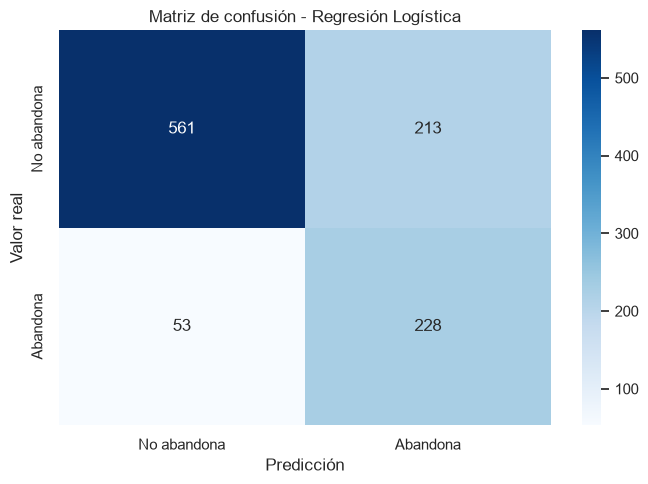

In [48]:
matriz_logistico = confusion_matrix(
    y_validation,
    pred_logistico_validation,
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_logistico,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No abandona",
        "Abandona",
    ],
    yticklabels=[
        "No abandona",
        "Abandona",
    ],
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "05_matriz_logistica_validation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretación de la Regresión Logística

La Regresión Logística balanceada detecta el 81,14% de los abandonos reales,
superando ampliamente al modelo base. Su ROC-AUC de 85,31% y PR-AUC de 65,42%
indican una buena capacidad para diferenciar clientes de mayor y menor riesgo.

La precision de 51,70% muestra que se generan algunas falsas alertas. Este
comportamiento puede ser aceptable si el objetivo del negocio es priorizar la
detección temprana y evitar perder clientes de alto riesgo.

## 5. Random Forest balanceado

Se entrena un modelo de árboles para capturar relaciones no lineales e
interacciones entre las características de los clientes.

In [49]:
modelo_random_forest = Pipeline(
    steps=[
        (
            "preprocesamiento",
            clone(preprocesador),
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

modelo_random_forest.fit(
    X_train,
    y_train,
)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.


In [50]:
pred_rf_validation = modelo_random_forest.predict(
    X_validation
)

prob_rf_validation = modelo_random_forest.predict_proba(
    X_validation
)[:, 1]

metricas_rf = calcular_metricas(
    nombre_modelo="Random Forest balanceado",
    valores_reales=y_validation,
    predicciones=pred_rf_validation,
    probabilidades=prob_rf_validation,
)

resultados_modelos.append(metricas_rf)

display(
    pd.DataFrame(resultados_modelos)
    .round(4)
)

,Modelo,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,DummyClassifier,0.7336,0.5000,0.0000,0.0000,0.0000,0.5000,0.2664
1,Regresión Logística L2 balanceada,0.7479,0.7681,0.5170,0.8114,0.6316,0.8531,0.6542
2,Random Forest balanceado,0.7697,0.7546,0.5516,0.7224,0.6256,0.8341,0.6380


Por ahora, la Regresión Logística es mejor para detectar abandonos, porque identifica el 81,14% de los casos reales. Random Forest genera menos falsas alertas, pero deja sin detectar más clientes.

## 6. Gradient Boosting

Se entrena un modelo de boosting que construye árboles secuencialmente,
corrigiendo los errores cometidos por los árboles anteriores.

In [51]:
modelo_gradient_boosting = Pipeline(
    steps=[
        (
            "preprocesamiento",
            clone(preprocesador),
        ),
        (
            "modelo",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

modelo_gradient_boosting.fit(
    X_train,
    y_train,
)

print("Gradient Boosting entrenado correctamente.")

Gradient Boosting entrenado correctamente.


In [52]:
pred_gb_validation = modelo_gradient_boosting.predict(
    X_validation
)

prob_gb_validation = modelo_gradient_boosting.predict_proba(
    X_validation
)[:, 1]

metricas_gb = calcular_metricas(
    nombre_modelo="Gradient Boosting",
    valores_reales=y_validation,
    predicciones=pred_gb_validation,
    probabilidades=prob_gb_validation,
)

resultados_modelos.append(metricas_gb)

tabla_comparacion = (
    pd.DataFrame(resultados_modelos)
    .sort_values(
        by="ROC_AUC",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    tabla_comparacion.round(4)
)

,Modelo,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Regresión Logística L2 balanceada,0.7479,0.7681,0.5170,0.8114,0.6316,0.8531,0.6542
1,Gradient Boosting,0.8066,0.7163,0.6774,0.5231,0.5904,0.8497,0.6845
2,Random Forest balanceado,0.7697,0.7546,0.5516,0.7224,0.6256,0.8341,0.6380
3,DummyClassifier,0.7336,0.5000,0.0000,0.0000,0.0000,0.5000,0.2664


## 7. Selección del modelo

Se selecciona la Regresión Logística L2 balanceada como modelo principal. Aunque
Gradient Boosting presenta mayor accuracy y precision, la Regresión Logística
obtiene el recall, balanced accuracy y ROC-AUC más altos.

Debido a que el objetivo de negocio es detectar anticipadamente a los clientes
con riesgo de abandono, se prioriza la capacidad de detección de la clase
positiva por sobre la accuracy general.

In [53]:
from sklearn.metrics import precision_recall_curve

precisiones, recalls, umbrales = precision_recall_curve(
    y_validation,
    prob_logistico_validation,
)

tabla_umbrales = pd.DataFrame(
    {
        "Umbral": umbrales,
        "Precision": precisiones[:-1],
        "Recall": recalls[:-1],
    }
)

tabla_umbrales["F1"] = (
    2
    * tabla_umbrales["Precision"]
    * tabla_umbrales["Recall"]
    / (
        tabla_umbrales["Precision"]
        + tabla_umbrales["Recall"]
        + 1e-10
    )
)

candidatos = tabla_umbrales[
    tabla_umbrales["Recall"] >= 0.80
].copy()

fila_seleccionada = (
    candidatos
    .sort_values(
        by=["Precision", "F1"],
        ascending=False,
    )
    .iloc[0]
)

UMBRAL_OPERATIVO = float(
    fila_seleccionada["Umbral"]
)

print(
    "Umbral operativo:",
    round(UMBRAL_OPERATIVO, 4),
)

display(
    fila_seleccionada
    .to_frame()
    .T
    .round(4)
)

Umbral operativo: 0.5256


,Umbral,Precision,Recall,F1
628,0.5256,0.5294,0.8007,0.6374


## 8. Evaluación final en TEST

Después de seleccionar el modelo y el umbral mediante VALIDATION, se reentrena
la Regresión Logística utilizando conjuntamente TRAIN y VALIDATION.

Finalmente, el modelo se evalúa una sola vez sobre TEST, conjunto que no
participó en el entrenamiento ni en la selección del modelo.

In [54]:
df_train_final = pd.concat(
    [
        df_train,
        df_validation,
    ],
    ignore_index=True,
)

X_train_final = df_train_final.drop(
    columns=COLUMNAS_EXCLUIDAS
)

y_train_final = df_train_final["Churn"]

print(
    "Registros para entrenamiento final:",
    len(df_train_final),
)

print(
    "Registros reservados para TEST:",
    len(df_test),
)

Registros para entrenamiento final: 5977
Registros reservados para TEST: 1055


In [55]:
modelo_final = clone(
    modelo_logistico
)

modelo_final.fit(
    X_train_final,
    y_train_final,
)

print(
    "Modelo final entrenado con TRAIN + VALIDATION."
)

Modelo final entrenado con TRAIN + VALIDATION.


c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [56]:
probabilidades_test = modelo_final.predict_proba(
    X_test
)[:, 1]

predicciones_test = (
    probabilidades_test
    >= UMBRAL_OPERATIVO
).astype(int)

metricas_test = calcular_metricas(
    nombre_modelo="Regresión Logística - TEST final",
    valores_reales=y_test,
    predicciones=predicciones_test,
    probabilidades=probabilidades_test,
)

display(
    pd.DataFrame([metricas_test])
    .round(4)
)

,Modelo,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Regresión Logística - TEST final,0.7374,0.7392,0.5036,0.7429,0.6003,0.8224,0.5835


In [57]:
matriz_test = confusion_matrix(
    y_test,
    predicciones_test,
)

matriz_test_df = pd.DataFrame(
    matriz_test,
    index=[
        "Real: No abandona",
        "Real: Abandona",
    ],
    columns=[
        "Predice: No abandona",
        "Predice: Abandona",
    ],
)

display(matriz_test_df)

,Predice: No abandona,Predice: Abandona
Real: No abandona,570,205
Real: Abandona,72,208


A partir de esta matriz:

Recall: 208 / 280 = 74,29%.
Precision: 208 / 413 = 50,36%.
Accuracy: 778 / 1055 = 73,74%.
Balanced Accuracy: aproximadamente 73,92%.
F1: aproximadamente 60,03%.

El resultado principal puede expresarse así:

El modelo identificó correctamente 208 de los 280 clientes que abandonaron la empresa, equivalente a una capacidad de detección de 74,29%.

In [58]:
metricas_test_vertical = (
    pd.Series(metricas_test)
    .to_frame(name="Resultado")
)

display(metricas_test_vertical)

,Resultado
Modelo,Regresión Logística - TEST final
Accuracy,0.737441
Balanced_Accuracy,0.739171
Precision,0.503632
Recall,0.742857
F1,0.600289
ROC_AUC,0.822394
PR_AUC,0.583521


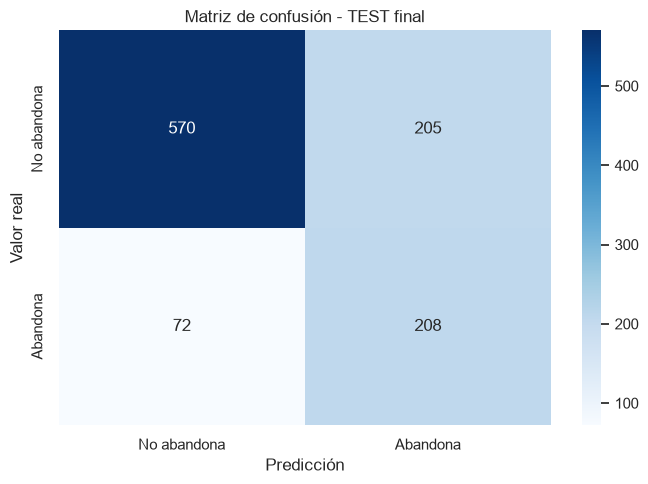

In [59]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No abandona",
        "Abandona",
    ],
    yticklabels=[
        "No abandona",
        "Abandona",
    ],
)

plt.title("Matriz de confusión - TEST final")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "06_matriz_test_final.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 9. Guardado del modelo y artefactos

Se guarda el pipeline completo, incluyendo el preprocesamiento y la Regresión
Logística. También se exportan el umbral operativo, las métricas finales y las
predicciones realizadas sobre TEST.

In [60]:
MODEL_PATH = (
    MODELS_PATH
    / "modelo_logistico_churn_v1.joblib"
)

joblib.dump(
    modelo_final,
    MODEL_PATH,
)

print("Modelo guardado en:")
print(MODEL_PATH)
print("¿Existe?:", MODEL_PATH.exists())

Modelo guardado en:
c:\Users\vfuen\Documents\telco-customer-churn-mle2\models\modelo_logistico_churn_v1.joblib
¿Existe?: True


In [61]:
import json

METADATA_PATH = (
    MODELS_PATH
    / "metadata_modelo_v1.json"
)

metadata_modelo = {
    "nombre_modelo": "Regresión Logística L2 balanceada",
    "version": "1.0.0",
    "variable_objetivo": "Churn",
    "umbral_operativo": UMBRAL_OPERATIVO,
    "random_state": RANDOM_STATE,
    "registros_entrenamiento": len(df_train_final),
    "registros_test": len(df_test),
    "cantidad_predictores": X_train_final.shape[1],
    "predictores": X_train_final.columns.tolist(),
    "metricas_test": {
        clave: float(valor)
        for clave, valor in metricas_test.items()
        if clave != "Modelo"
    },
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        metadata_modelo,
        archivo,
        ensure_ascii=False,
        indent=4,
    )

print("Metadata guardada en:")
print(METADATA_PATH)
print("¿Existe?:", METADATA_PATH.exists())

Metadata guardada en:
c:\Users\vfuen\Documents\telco-customer-churn-mle2\models\metadata_modelo_v1.json
¿Existe?: True


In [62]:
METRICS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "metricas_test_final.csv"
)

pd.DataFrame([metricas_test]).to_csv(
    METRICS_PATH,
    index=False,
)

print("Métricas guardadas en:")
print(METRICS_PATH)

Métricas guardadas en:
c:\Users\vfuen\Documents\telco-customer-churn-mle2\reports\metricas_test_final.csv


In [63]:
resultados_test = df_test[
    [
        "customerID",
        "Churn",
    ]
].copy()

resultados_test = resultados_test.rename(
    columns={
        "Churn": "Churn_real",
    }
)

resultados_test["Probabilidad_Churn"] = (
    probabilidades_test
)

resultados_test["Prediccion_Churn"] = (
    predicciones_test
)

resultados_test["Alerta"] = np.where(
    resultados_test["Probabilidad_Churn"]
    >= UMBRAL_OPERATIVO,
    "Sí",
    "No",
)

resultados_test = resultados_test.sort_values(
    by="Probabilidad_Churn",
    ascending=False,
).reset_index(drop=True)

display(resultados_test.head(10))

,customerID,Churn_real,Probabilidad_Churn,Prediccion_Churn,Alerta
0,2720-WGKHP,1,0.936605,1,Sí
1,5150-ITWWB,0,0.934976,1,Sí
2,1069-XAIEM,1,0.923932,1,Sí
3,8161-QYMTT,0,0.916661,1,Sí
4,9681-OXGVC,1,0.916654,1,Sí
5,2865-TCHJW,1,0.915869,1,Sí
6,6521-YYTYI,1,0.914327,1,Sí
7,8414-MYSHR,1,0.911577,1,Sí
8,4912-PIGUY,0,0.910975,1,Sí
9,0970-ETWGE,1,0.909993,1,Sí


In [64]:
PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "predicciones_test_final.csv"
)

resultados_test.to_csv(
    PREDICTIONS_PATH,
    index=False,
)

print("Predicciones guardadas en:")
print(PREDICTIONS_PATH)

print(
    "Cantidad de alertas:",
    resultados_test["Alerta"].eq("Sí").sum(),
)

Predicciones guardadas en:
c:\Users\vfuen\Documents\telco-customer-churn-mle2\reports\predicciones_test_final.csv
Cantidad de alertas: 413


In [65]:
artefactos = {
    "Modelo": MODEL_PATH.exists(),
    "Metadata": METADATA_PATH.exists(),
    "Métricas": METRICS_PATH.exists(),
    "Predicciones": PREDICTIONS_PATH.exists(),
}

display(
    pd.Series(artefactos)
    .to_frame(name="Existe")
)

,Existe
Modelo,True
Metadata,True
Métricas,True
Predicciones,True


## 10. Registro de experimentos con MLflow

MLflow se utiliza para registrar los modelos entrenados, sus parámetros,
métricas y artefactos. Los experimentos se almacenarán localmente dentro de la
carpeta `mlruns`.

In [67]:
import mlflow
import mlflow.sklearn

MLFLOW_DB_PATH = (
    PROJECT_ROOT
    / "mlflow.db"
).resolve()

MLFLOW_TRACKING_URI = (
    f"sqlite:///{MLFLOW_DB_PATH.as_posix()}"
)

mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)

experimento = mlflow.set_experiment(
    experiment_name="telco_customer_churn"
)

print(
    "MLflow configurado correctamente."
)

print(
    "Tracking URI:",
    mlflow.get_tracking_uri(),
)

print(
    "Experimento:",
    experimento.name,
)

2026/09/06 12:03:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/06 12:03:44 INFO mlflow.store.db.utils: Updating database tables
2026/09/06 12:03:46 INFO mlflow.tracking.fluent: Experiment with name 'telco_customer_churn' does not exist. Creating a new experiment.


MLflow configurado correctamente.
Tracking URI: sqlite:///C:/Users/vfuen/Documents/telco-customer-churn-mle2/mlflow.db
Experimento: telco_customer_churn


In [70]:
def registrar_experimento(
    nombre_run,
    modelo,
    metricas,
    parametros,
):
    """Registra parámetros, métricas y modelo en MLflow."""

    metricas_mlflow = {
        clave.lower(): float(valor)
        for clave, valor in metricas.items()
        if clave != "Modelo"
    }

    with mlflow.start_run(
        run_name=nombre_run
    ):
        mlflow.log_params(
            parametros
        )

        mlflow.log_metrics(
            metricas_mlflow
        )

        mlflow.set_tags(
            {
                "dataset": "Telco Customer Churn",
                "tipo_problema": "Clasificación binaria",
                "conjunto_evaluacion": "Validation",
                "variable_objetivo": "Churn",
            }
        )

        mlflow.sklearn.log_model(
        sk_model=modelo,
        name="modelo",
         input_example=X_validation.head(5),
        serialization_format=(
        mlflow.sklearn
        .SERIALIZATION_FORMAT_CLOUDPICKLE
    ),
)

        run_id = mlflow.active_run().info.run_id

    print(
        f"Experimento registrado: {nombre_run}"
    )

    return run_id


print("Función MLflow creada correctamente.")

Función MLflow creada correctamente.


In [71]:
run_dummy = registrar_experimento(
    nombre_run="01_dummy_classifier",
    modelo=modelo_dummy,
    metricas=metricas_dummy,
    parametros={
        "modelo": "DummyClassifier",
        "strategy": "most_frequent",
    },
)

print("Run ID:", run_dummy)

2026/09/06 12:07:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may 

Experimento registrado: 01_dummy_classifier
Run ID: b9101240547f414581ad25dc46823aa7


In [72]:
run_logistico = registrar_experimento(
    nombre_run="02_regresion_logistica",
    modelo=modelo_logistico,
    metricas=metricas_logistico,
    parametros={
        "modelo": "LogisticRegression",
        "penalty": "l2",
        "class_weight": "balanced",
        "max_iter": 2000,
        "umbral": 0.50,
    },
)

run_random_forest = registrar_experimento(
    nombre_run="03_random_forest",
    modelo=modelo_random_forest,
    metricas=metricas_rf,
    parametros={
        "modelo": "RandomForestClassifier",
        "n_estimators": 300,
        "min_samples_leaf": 2,
        "class_weight": "balanced",
    },
)

run_gradient_boosting = registrar_experimento(
    nombre_run="04_gradient_boosting",
    modelo=modelo_gradient_boosting,
    metricas=metricas_gb,
    parametros={
        "modelo": "GradientBoostingClassifier",
        "n_estimators": 150,
        "learning_rate": 0.05,
        "max_depth": 3,
    },
)

print("\nTres experimentos adicionales registrados.")
print("Logística:", run_logistico)
print("Random Forest:", run_random_forest)
print("Gradient Boosting:", run_gradient_boosting)

2026/09/06 12:10:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may 

Experimento registrado: 02_regresion_logistica


c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missi

Experimento registrado: 03_random_forest


c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missi

Experimento registrado: 04_gradient_boosting

Tres experimentos adicionales registrados.
Logística: f6924c50c0d74c55ae4720476cc8f9ae
Random Forest: fe398510179947cea8eaf058da70cf8e
Gradient Boosting: 9a8291607c724bfda50873d137950c68


## 11. Registro del modelo productivo

Se registra la Regresión Logística reentrenada con TRAIN y VALIDATION. El modelo
fue evaluado una sola vez sobre TEST utilizando el umbral operativo definido
previamente.

In [73]:
from mlflow.models import infer_signature

firma_modelo = infer_signature(
    X_test,
    modelo_final.predict(X_test),
)

metricas_test_mlflow = {
    clave.lower(): float(valor)
    for clave, valor in metricas_test.items()
    if clave != "Modelo"
}

with mlflow.start_run(
    run_name="05_modelo_productivo_v1"
) as run_productivo:

    mlflow.log_params(
        {
            "modelo": "LogisticRegression",
            "penalty": "l2",
            "class_weight": "balanced",
            "max_iter": 2000,
            "umbral_operativo": UMBRAL_OPERATIVO,
            "version": "1.0.0",
            "train_final": len(df_train_final),
            "test_final": len(df_test),
        }
    )

    mlflow.log_metrics(
        metricas_test_mlflow
    )

    mlflow.set_tags(
        {
            "dataset": "Telco Customer Churn",
            "tipo_problema": "Clasificación binaria",
            "conjunto_evaluacion": "TEST",
            "estado_modelo": "Productivo",
            "version_modelo": "1.0.0",
            "variable_objetivo": "Churn",
        }
    )

    mlflow.log_artifact(
        str(METADATA_PATH),
        artifact_path="documentacion",
    )

    mlflow.log_artifact(
        str(METRICS_PATH),
        artifact_path="resultados",
    )

    mlflow.log_artifact(
        str(PREDICTIONS_PATH),
        artifact_path="resultados",
    )

    matriz_final_path = (
        FIGURES_PATH
        / "06_matriz_test_final.png"
    )

    if matriz_final_path.exists():
        mlflow.log_artifact(
            str(matriz_final_path),
            artifact_path="graficos",
        )

    mlflow.sklearn.log_model(
        sk_model=modelo_final,
        name="modelo_productivo",
        registered_model_name="telco_churn_model",
        input_example=X_test.head(5),
        signature=firma_modelo,
        serialization_format=(
            mlflow.sklearn
            .SERIALIZATION_FORMAT_CLOUDPICKLE
        ),
    )

    run_id_productivo = (
        run_productivo.info.run_id
    )

print(
    "Modelo productivo registrado correctamente."
)

print(
    "Run ID productivo:",
    run_id_productivo,
)

c:\Users\vfuen\Documents\telco-customer-churn-mle2\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/06 12:17:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which c

Modelo productivo registrado correctamente.
Run ID productivo: acff5b59cabd4a7eb40be4c6ef57c1d4


Successfully registered model 'telco_churn_model'.
Created version '1' of model 'telco_churn_model'.
